<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/codigo_correcao_camargo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Climas do Brasil — mapas por município (Camargo + variáveis climáticas)

Corrige o problema dos municípios faltantes e plota, em capítulos, a classificação de Camargo (1991)
modificada por Maluf (2000) e as variáveis climáticas do CSV.

**Por que faltavam municípios:** a amostragem no centroide (feita no GEE em ~5 km) não retorna valor
para municípios de área pequena — o centroide cai numa célula sem dado válido. A correção preenche os
faltantes em duas etapas: (1) casa por nome normalizado + UF; (2) para todo município oficial que
sobrar sem dado, copia do **vizinho geográfico mais próximo** que tenha classificação. Resultado: mapa
100% preenchido.

## 1. Bibliotecas

In [1]:
!pip install geobr geopandas cartopy matplotlib-scalebar scipy --quiet

import numpy as np
import pandas as pd
import unicodedata
import requests
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.spatial import cKDTree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.8 MB/s eta 0:00:00


## 2. Carregar o CSV de classificação

In [2]:
url = 'https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/camargo_municipios_brasil_completo.csv'
df_camargo = pd.read_csv(url, sep=',')
print('Linhas no CSV:', len(df_camargo))
df_camargo.head()

Linhas no CSV: 5508


,system:index,UF,UF_codigo_gaul,camargo_completo,cm_hidrico,cm_hidrico_codigo,cm_letra_seca,cm_termico,cm_termico_codigo,def_anual_mm,excedente_anual_mm,latitude,longitude,municipio,municipio_codigo_gaul,temp_anual_c,temp_mes_mais_frio_c,.geo
0,000000000000000015bd_0,Alagoas,666,TR-SEp,SE,3,p,TR,7,726.256664,69.666665,-9.275105,-37.886447,Agua Branca,6355,23.367361,19.991667,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,000000000000000015be_0,Alagoas,666,TR-SEv,SE,3,v,TR,7,453.293327,176.933332,-9.679347,-36.314395,Anadia,6356,23.851250,21.350000,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,000000000000000015bf_0,Alagoas,666,TR-SEv,SE,3,v,TR,7,682.256670,46.066666,-9.769179,-36.628806,Arapiraca,6357,23.783056,21.061666,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,000000000000000015c0_0,Alagoas,666,TR-MOv,MO,4,v,TR,7,366.873332,351.933334,-9.499684,-36.089817,Atalaia,6358,23.925417,21.588333,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,000000000000000015c1_0,Alagoas,666,TR-MOv,MO,4,v,TR,7,248.343334,641.866677,-9.364937,-35.550827,Barra De Santo Antonio,6359,24.498611,22.656666,"{""type"":""MultiPoint"",""coordinates"":[]}"


## 3. Legenda, paleta e utilitários

In [3]:
# Camargo (1991) mod. Maluf (2000) — classe térmica (mapa principal) e classe hídrica
CM_TERMICO_LABELS = {1:'GL', 2:'FR', 3:'CO', 4:'TE', 5:'STE', 6:'ST', 7:'TR', 8:'EQ'}
CM_TERMICO_NOMES = {
    1:'Gélido', 2:'Frio', 3:'Frio moderado', 4:'Temperado', 5:'Subtemperado',
    6:'Subtropical', 7:'Tropical', 8:'Equatorial'
}
CM_TERMICO_COLORS = {
    1:'#4575b4', 2:'#74add1', 3:'#abd9e9', 4:'#fee08b', 5:'#fdae61', 6:'#f46d43', 7:'#d73027', 8:'#a50026'
}

CM_HIDRICO_LABELS = {1:'DE', 2:'AR', 3:'SE', 4:'MO', 5:'SB', 6:'UM', 7:'PU', 8:'SU'}
CM_HIDRICO_NOMES = {
    1:'Desértico', 2:'Árido', 3:'Seco', 4:'Monçônico', 5:'Subúmido', 6:'Úmido',
    7:'Superúmido', 8:'Extremamente úmido'
}
CM_HIDRICO_COLORS = {
    1:'#8c510a', 2:'#d8b365', 3:'#f6e8c3', 4:'#fee08b', 5:'#c7eae5', 6:'#5ab4ac', 7:'#01807a', 8:'#003c30'
}

def normalize(s):
    if pd.isna(s):
        return ''
    return ''.join(c for c in unicodedata.normalize('NFKD', str(s)) if not unicodedata.combining(c)).upper().strip()

STATE_ABBR = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPA':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARA':'CE',
    'DISTRITO FEDERAL':'DF','ESPIRITO SANTO':'ES','GOIAS':'GO','MARANHAO':'MA','MATO GROSSO':'MT',
    'MATO GROSSO DO SUL':'MS','MINAS GERAIS':'MG','PARA':'PA','PARAIBA':'PB','PARANA':'PR',
    'PERNAMBUCO':'PE','PIAUI':'PI','RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN',
    'RIO GRANDE DO SUL':'RS','RONDONIA':'RO','RORAIMA':'RR','SANTA CATARINA':'SC','SAO PAULO':'SP',
    'SERGIPE':'SE','TOCANTINS':'TO',
}

## 4. Limites municipais e estaduais (geobr — Brasil inteiro)

In [4]:
municipios_gdf = geobr.read_municipality(code_muni='all', year=2020).to_crs(epsg=4326)
estados_gdf = geobr.read_state(code_state='all', year=2020).to_crs(epsg=4326)
print(f'geobr trouxe {len(municipios_gdf)} municípios e {len(estados_gdf)} estados.')

# ponto representativo interno (garantidamente dentro do polígono, mesmo em formatos côncavos)
municipios_gdf['pt_interno'] = municipios_gdf.geometry.representative_point()
municipios_gdf['lon_c'] = municipios_gdf['pt_interno'].x
municipios_gdf['lat_c'] = municipios_gdf['pt_interno'].y
municipios_gdf['municipio_norm'] = municipios_gdf['name_muni'].apply(normalize)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:00<00:00, 137MB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage

geobr trouxe 5570 municípios e 27 estados.


## 5. (Conferência) lista oficial de municípios do IBGE

In [5]:
# Fonte primária: API oficial do IBGE. Se estiver indisponível, cai no espelho do GitHub.
try:
    resp = requests.get('https://servicodados.ibge.gov.br/api/v1/localidades/municipios', timeout=30)
    resp.raise_for_status()
    ibge_json = resp.json()
    def _extrai_uf(m):
        try:
            return m['microrregiao']['mesorregiao']['UF']['sigla']
        except (KeyError, TypeError):
            return m['regiao-imediata']['regiao-intermediaria']['UF']['sigla']
    ibge_ref = pd.DataFrame([{'codigo_ibge': m['id'], 'nome_ibge': m['nome'],
                              'uf_sigla': _extrai_uf(m)} for m in ibge_json])
    print('Lista IBGE (API oficial):', len(ibge_ref), 'municípios.')
except Exception as e:
    print('API do IBGE indisponível (', e, ') — usando espelho do GitHub.')
    ibge_ref = pd.read_csv('https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv')
    ufs_ref = pd.read_csv('https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/estados.csv')
    ibge_ref['uf_sigla'] = ibge_ref['codigo_uf'].map(dict(zip(ufs_ref['codigo_uf'], ufs_ref['uf'])))
    ibge_ref = ibge_ref.rename(columns={'nome': 'nome_ibge'})[['codigo_ibge', 'nome_ibge', 'uf_sigla']]
    print('Lista IBGE (espelho):', len(ibge_ref), 'municípios.')

Lista IBGE (API oficial): 5571 municípios.


## 6. Casamento por nome + UF, depois preenchimento por vizinho mais próximo

In [6]:
df = df_camargo.copy()
df['municipio_norm'] = df['municipio'].apply(normalize)
df['UF_sigla'] = df['UF'].apply(lambda x: STATE_ABBR.get(normalize(x)))

# Colunas de dado do CSV de Camargo (classes categóricas + variáveis do balanço hídrico)
COLUNAS_CLIMA = ['camargo_completo', 'cm_termico', 'cm_termico_codigo',
                 'cm_hidrico', 'cm_hidrico_codigo', 'cm_letra_seca',
                 'def_anual_mm', 'excedente_anual_mm', 'temp_anual_c', 'temp_mes_mais_frio_c']

# --- Etapa 1: casamento por nome normalizado + sigla de UF ---
juncao = municipios_gdf.merge(
    df[['municipio_norm', 'UF_sigla'] + COLUNAS_CLIMA],
    left_on=['municipio_norm', 'abbrev_state'],
    right_on=['municipio_norm', 'UF_sigla'],
    how='left'
).drop_duplicates(subset='code_muni', keep='first').reset_index(drop=True)

n_pos_nome = juncao['cm_termico_codigo'].isna().sum()
print(f'Após casamento por nome+UF: {n_pos_nome} município(s) ainda sem dado.')

Após casamento por nome+UF: 124 município(s) ainda sem dado.


In [7]:
# --- Etapa 2: preenche os faltantes pelo vizinho mais próximo (KDTree sobre lon/lat) ---
tem_dado = juncao[juncao['cm_termico_codigo'].notna()]
sem_dado = juncao[juncao['cm_termico_codigo'].isna()]

if len(sem_dado):
    tree = cKDTree(tem_dado[['lon_c', 'lat_c']].values)
    _, idx_vizinho = tree.query(sem_dado[['lon_c', 'lat_c']].values, k=1)
    vizinhos = tem_dado.iloc[idx_vizinho]
    for col in COLUNAS_CLIMA:
        juncao.loc[sem_dado.index, col] = vizinhos[col].values
    juncao.loc[sem_dado.index, 'preenchido_por_vizinho'] = True
    juncao['preenchido_por_vizinho'] = juncao['preenchido_por_vizinho'].fillna(False)
    print(f'Preenchidos por vizinho mais próximo: {len(sem_dado)} município(s).')
else:
    juncao['preenchido_por_vizinho'] = False

print(f'Municípios SEM dado ao final: {juncao["cm_termico_codigo"].isna().sum()}')
print(f'Total no mapa: {len(juncao)}')

Preenchidos por vizinho mais próximo: 124 município(s).
Municípios SEM dado ao final: 0
Total no mapa: 5570


/tmp/ipykernel_800/2484321378.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  juncao['preenchido_por_vizinho'] = juncao['preenchido_por_vizinho'].fillna(False)


In [8]:
# --- Conferência contra a lista oficial do IBGE ---
juncao_keys = set(zip(juncao['municipio_norm'], juncao['abbrev_state']))
faltam_no_mapa = ibge_ref[~ibge_ref.apply(lambda r: (normalize(r['nome_ibge']), r['uf_sigla']) in juncao_keys, axis=1)]
print(f'Municípios da lista IBGE ausentes do mapa geobr: {len(faltam_no_mapa)}')
if len(faltam_no_mapa):
    print('(normalmente municípios criados após o ano de referência do geobr)')
    print(faltam_no_mapa[['nome_ibge', 'uf_sigla']].to_string(index=False))

Municípios da lista IBGE ausentes do mapa geobr: 7
(normalmente municípios criados após o ano de referência do geobr)
                nome_ibge uf_sigla
        São Luiz do Anauá       RR
                     Assú       RN
                     Arez       RN
          Graccho Cardoso       SE
      Barão do Monte Alto       MG
   Boa Esperança do Norte       MT
Santo Antônio de Leverger       MT


## 7. Funções de plotagem (estilo cartopy padrão)

In [9]:
def _base_map(ax, titulo):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

def _decoracoes(ax, minx, miny, maxx, maxy):
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))

In [10]:
def plot_categorico(gdf, coluna_codigo, labels, nomes, colors, titulo, legenda_titulo, savepath=None):
    """Mapa de classes categóricas (térmica ou hídrica de Camargo)."""
    classes = sorted(gdf[coluna_codigo].dropna().unique().astype(int))
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    for c in classes:
        gdf[gdf[coluna_codigo] == c].plot(ax=ax, color=colors[c], edgecolor='none',
                                           transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    total = gdf[coluna_codigo].notna().sum()
    cont = gdf[coluna_codigo].value_counts()
    patches = [mpatches.Patch(facecolor=colors[c], edgecolor='black', linewidth=0.4,
                               label=f'{labels[c]} — {nomes[c]}  ({100*cont.get(c,0)/total:.1f}%)')
               for c in classes]
    ax.legend(handles=patches, title=legenda_titulo, loc='upper right', frameon=True, fontsize=8.5)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

In [11]:
def plot_continua(gdf, coluna, titulo, unidade, cmap_nome, savepath=None):
    dados = gdf.dropna(subset=[coluna])
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    vmin, vmax = dados[coluna].quantile([0.02, 0.98])   # evita outlier esticar a escala
    dados.plot(column=coluna, cmap=cmap_nome, vmin=vmin, vmax=vmax, ax=ax, edgecolor='none',
               transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    sm = plt.cm.ScalarMappable(cmap=cmap_nome, norm=plt.Normalize(vmin=vmin, vmax=vmax)); sm._A = []
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.035, pad=0.02, shrink=0.6)
    cbar.set_label(f'{titulo} ({unidade})', fontsize=10)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

## 8. Capítulo 1 — Classe térmica de Camargo

In [12]:
juncao.head()

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry,pt_interno,...,cm_termico,cm_termico_codigo,cm_hidrico,cm_hidrico_codigo,cm_letra_seca,def_anual_mm,excedente_anual_mm,temp_anual_c,temp_mes_mais_frio_c,preenchido_por_vizinho
0,1100015.0,Alta Floresta d'Oeste,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-62.19929 -11.82788, -62.18945 -11.8...",POINT (-62.13708 -12.47687),...,TR,7.0,MO,4.0,i,212.139999,557.433331,25.139166,23.733334,False
1,1100023.0,Ariquemes,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-62.53648 -9.73222, -62.52765 -9.736...",POINT (-63.0562 -9.97811),...,TR,7.0,MO,4.0,i,152.420000,1189.166675,25.682638,24.898333,False
2,1100031.0,Cabixi,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-60.37119 -13.36655, -60.37661 -13.3...",POINT (-60.67754 -13.50588),...,TR,7.0,MO,4.0,i,238.443335,600.599997,25.445833,23.531666,False
3,1100049.0,Cacoal,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-61.00059 -10.99224, -61.00103 -11.3...",POINT (-61.25092 -11.2239),...,TR,7.0,MO,4.0,i,195.323335,997.233310,24.789722,23.655000,False
4,1100056.0,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-61.50149 -13.00501, -61.49426 -13.0...",POINT (-61.20355 -13.18329),...,TR,7.0,MO,4.0,i,260.886671,518.200001,25.460278,23.668333,False


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scal

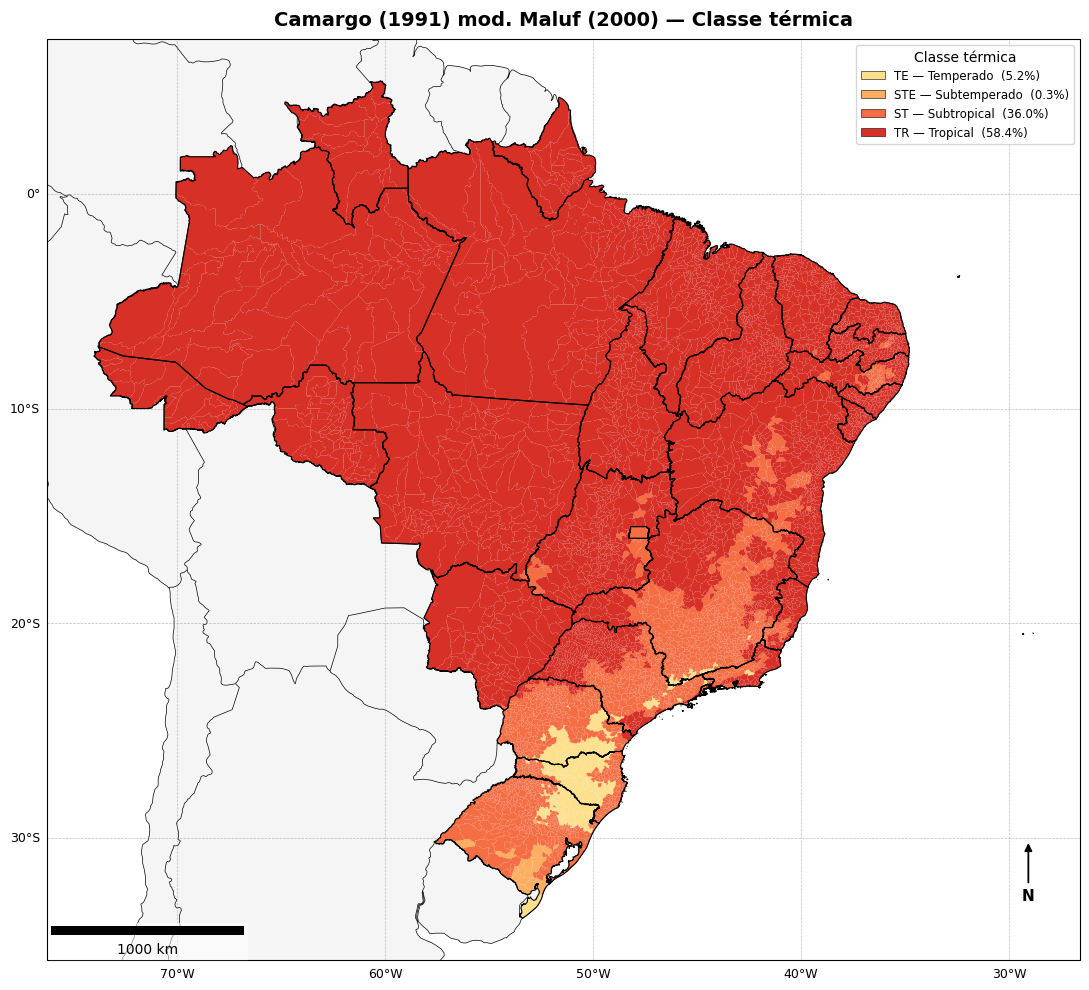

In [13]:
plot_categorico(juncao, 'cm_termico_codigo', CM_TERMICO_LABELS, CM_TERMICO_NOMES, CM_TERMICO_COLORS,
                'Camargo (1991) mod. Maluf (2000) — Classe térmica', 'Classe térmica',
                'camargo_termico.png')

## 9. Capítulo 2 — Classe hídrica de Camargo

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

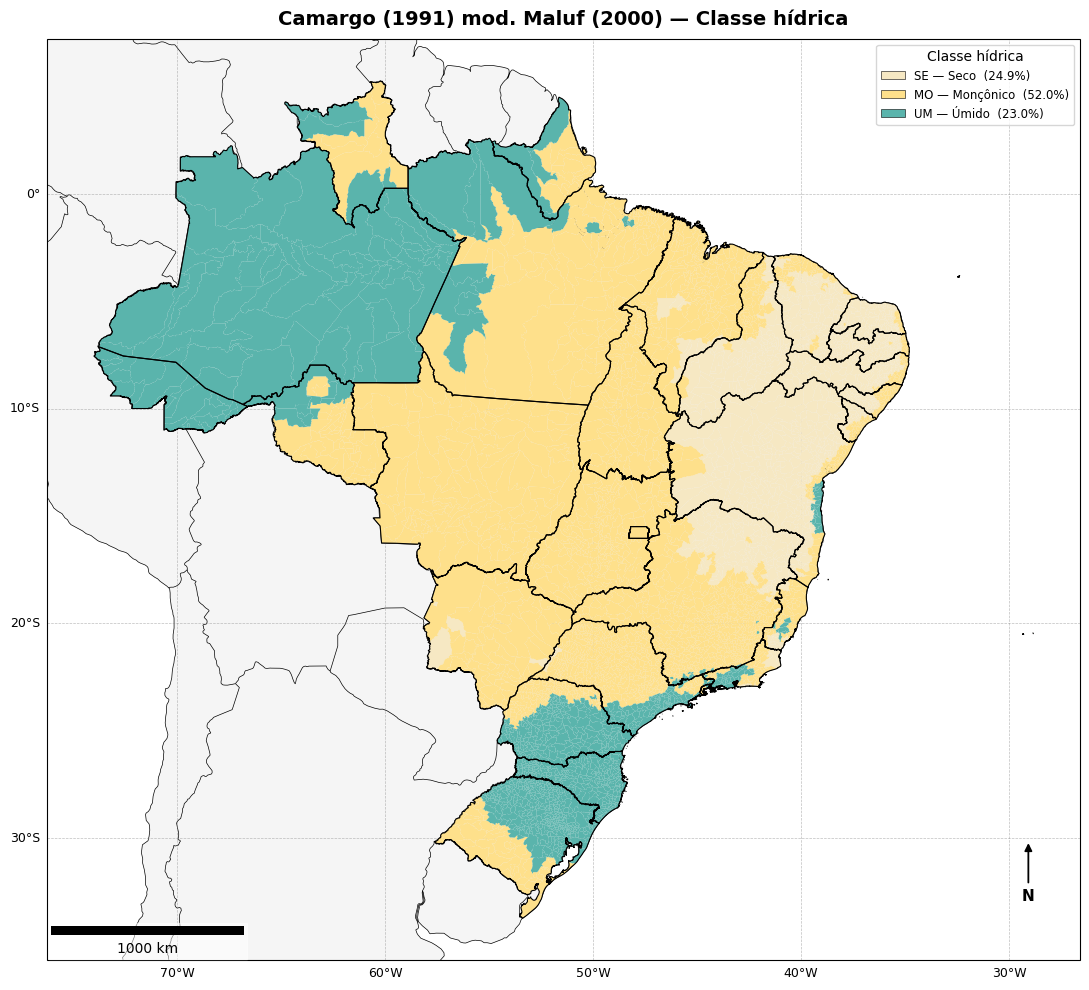

In [14]:
plot_categorico(juncao, 'cm_hidrico_codigo', CM_HIDRICO_LABELS, CM_HIDRICO_NOMES, CM_HIDRICO_COLORS,
                'Camargo (1991) mod. Maluf (2000) — Classe hídrica', 'Classe hídrica',
                'camargo_hidrico.png')

## 10. Capítulo 3 — Balanço hídrico

Deficiência e excedente hídrico anual (mm) usados na classificação hídrica de Camargo.

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

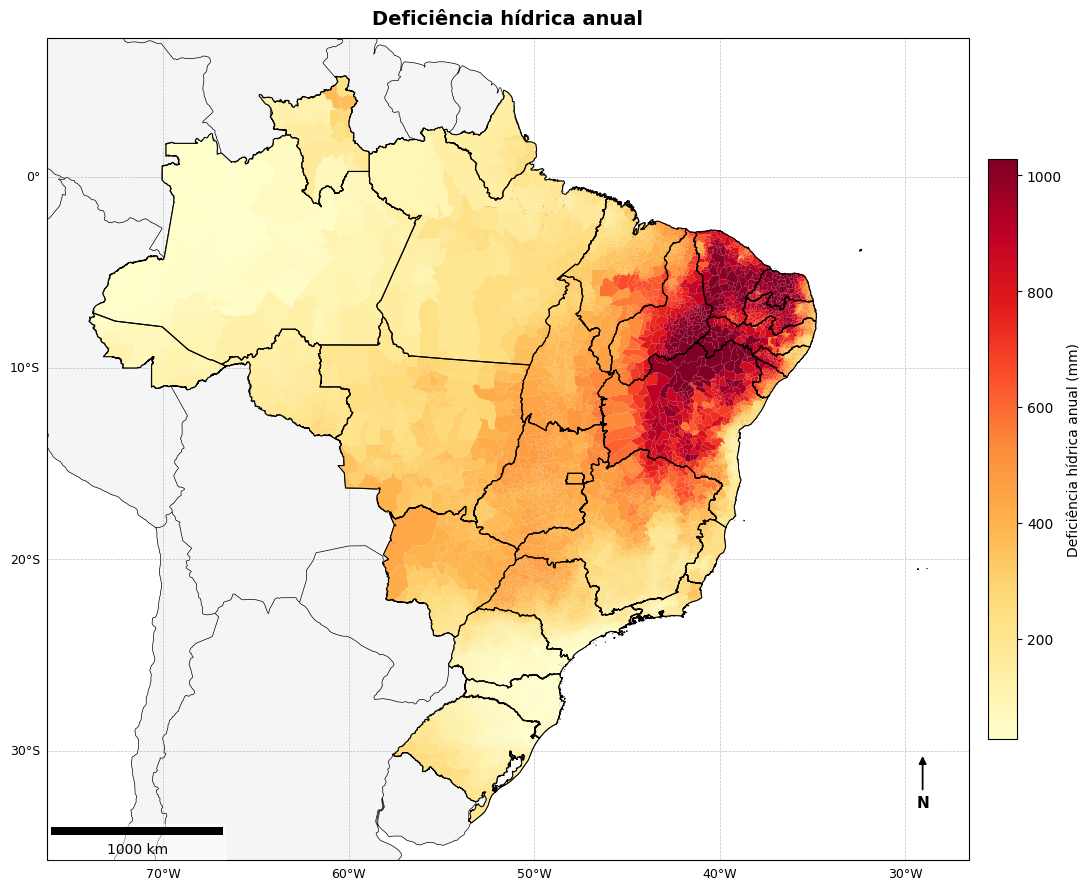

In [15]:
plot_continua(juncao, 'def_anual_mm', 'Deficiência hídrica anual',
              'mm', 'YlOrRd', 'def_anual.png')

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

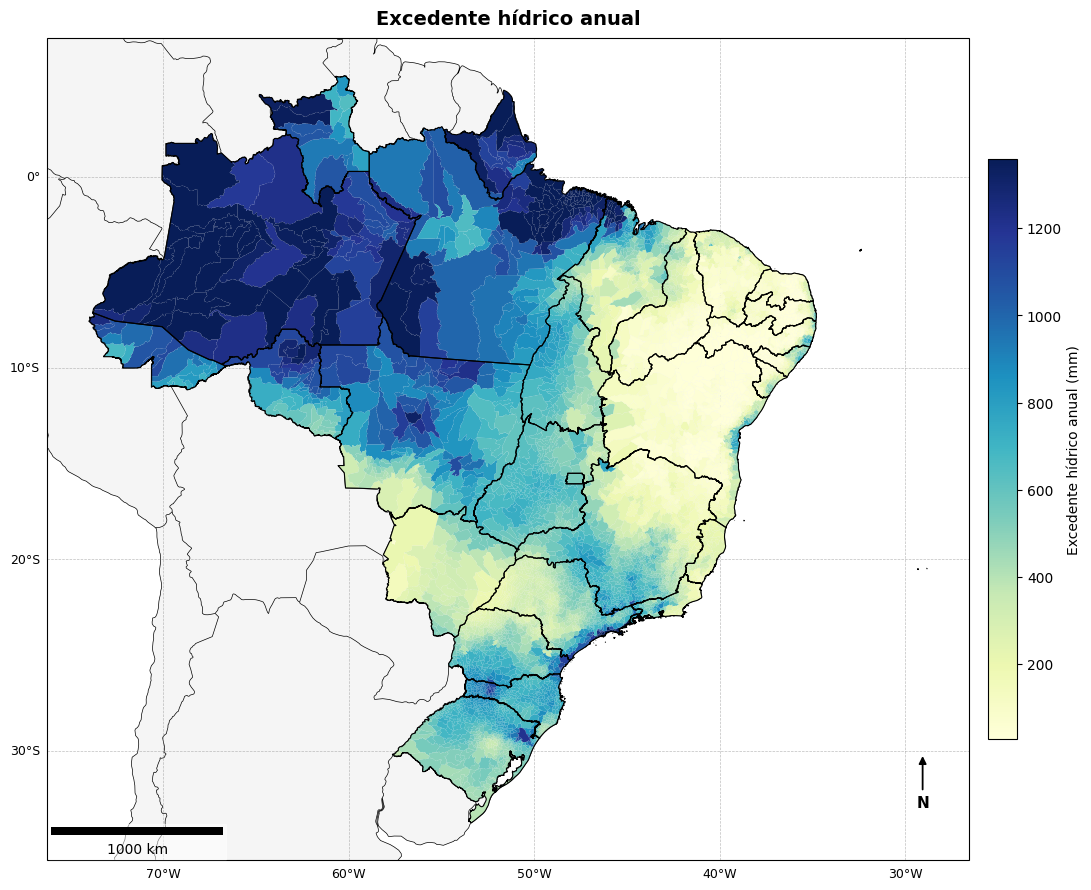

In [16]:
plot_continua(juncao, 'excedente_anual_mm', 'Excedente hídrico anual',
              'mm', 'YlGnBu', 'excedente_anual.png')

## 11. Capítulo 4 — Temperatura

Variáveis térmicas presentes no CSV de Camargo.

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

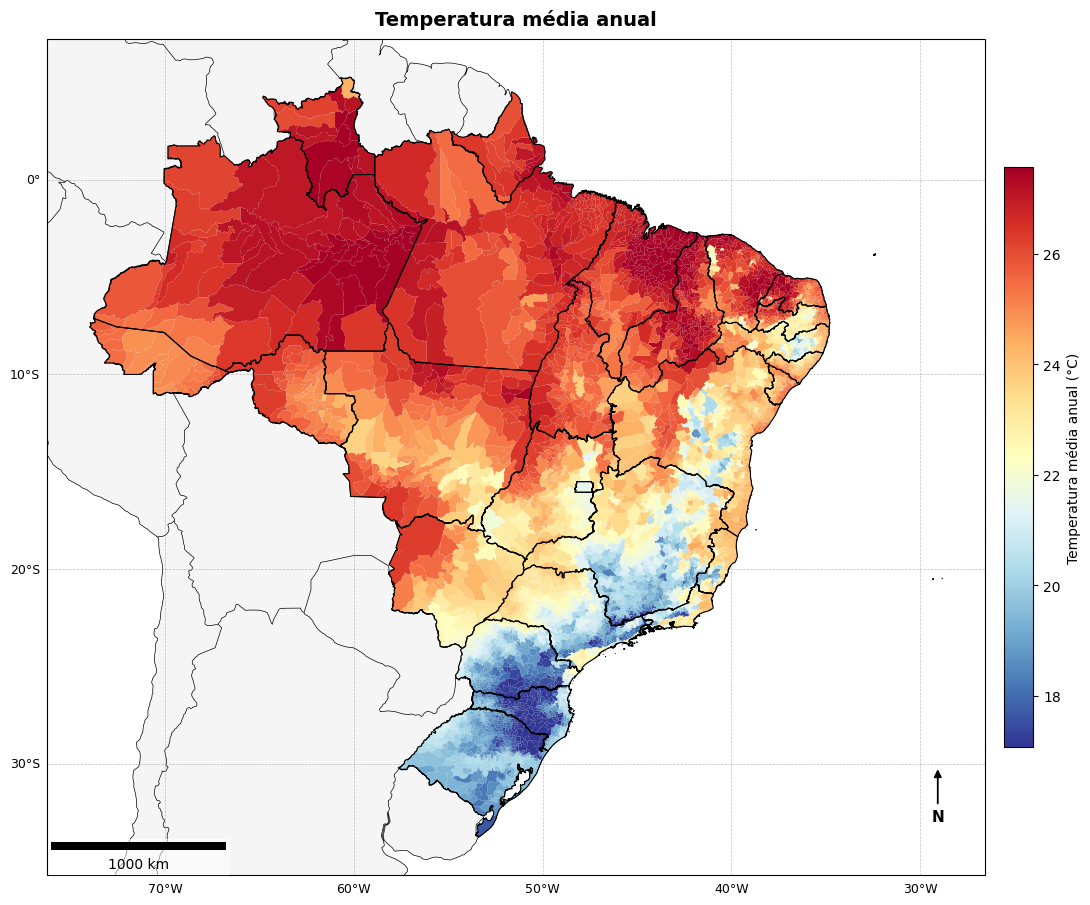

In [17]:
plot_continua(juncao, 'temp_anual_c', 'Temperatura média anual',
              '°C', 'RdYlBu_r', 'temp_anual.png')

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

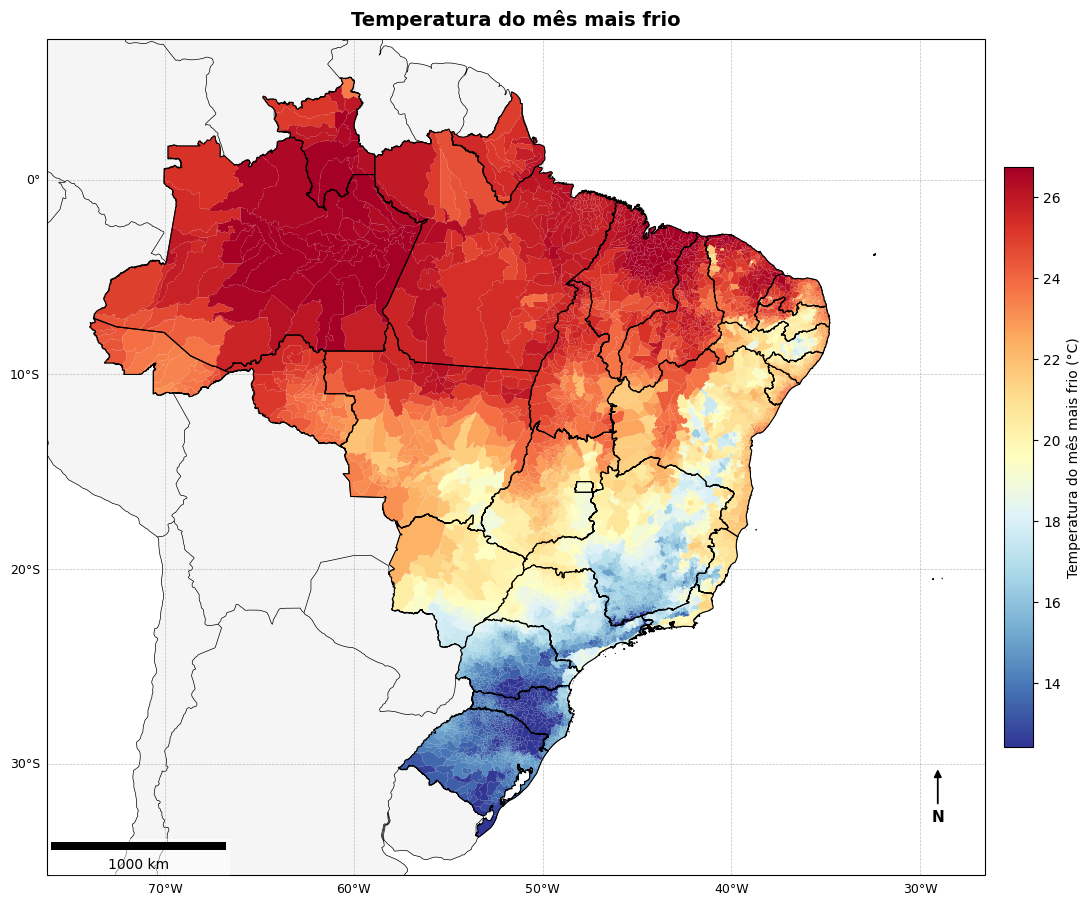

In [18]:
plot_continua(juncao, 'temp_mes_mais_frio_c', 'Temperatura do mês mais frio',
              '°C', 'RdYlBu_r', 'temp_mes_frio.png')

## 12. (Opcional) Salvar o resultado preenchido

Exporta o resultado com todos os municípios preenchidos, marcando quais vieram do vizinho mais
próximo (coluna `preenchido_por_vizinho`).

In [19]:
colunas_saida = ['code_muni', 'name_muni', 'abbrev_state'] + COLUNAS_CLIMA + ['preenchido_por_vizinho']
juncao[colunas_saida].to_csv('camargo_municipios_preenchido.csv', index=False)
print('Salvo: camargo_municipios_preenchido.csv')
print('Preenchidos por vizinho:', int(juncao['preenchido_por_vizinho'].sum()))

Salvo: camargo_municipios_preenchido.csv
Preenchidos por vizinho: 124
